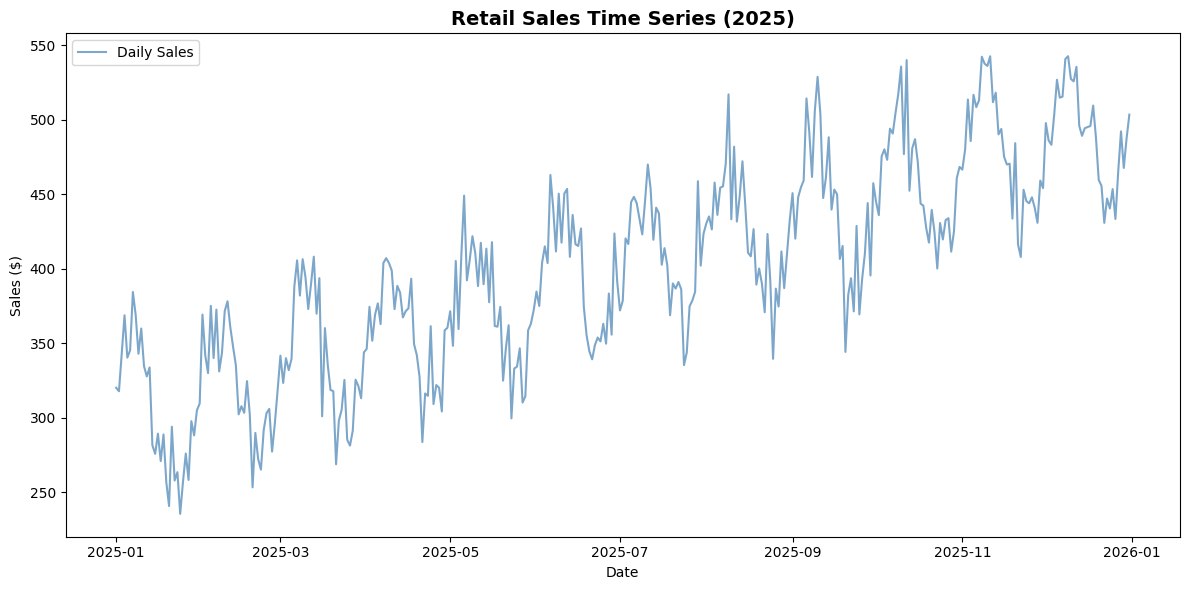

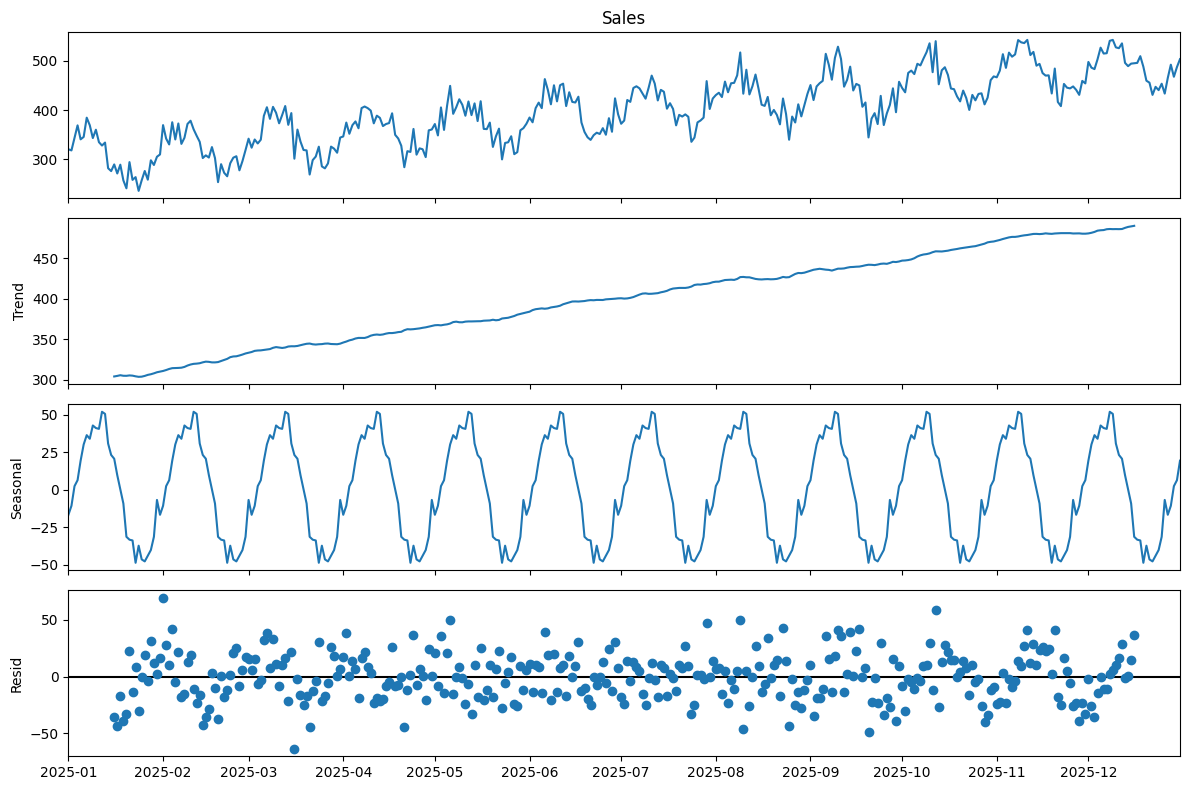

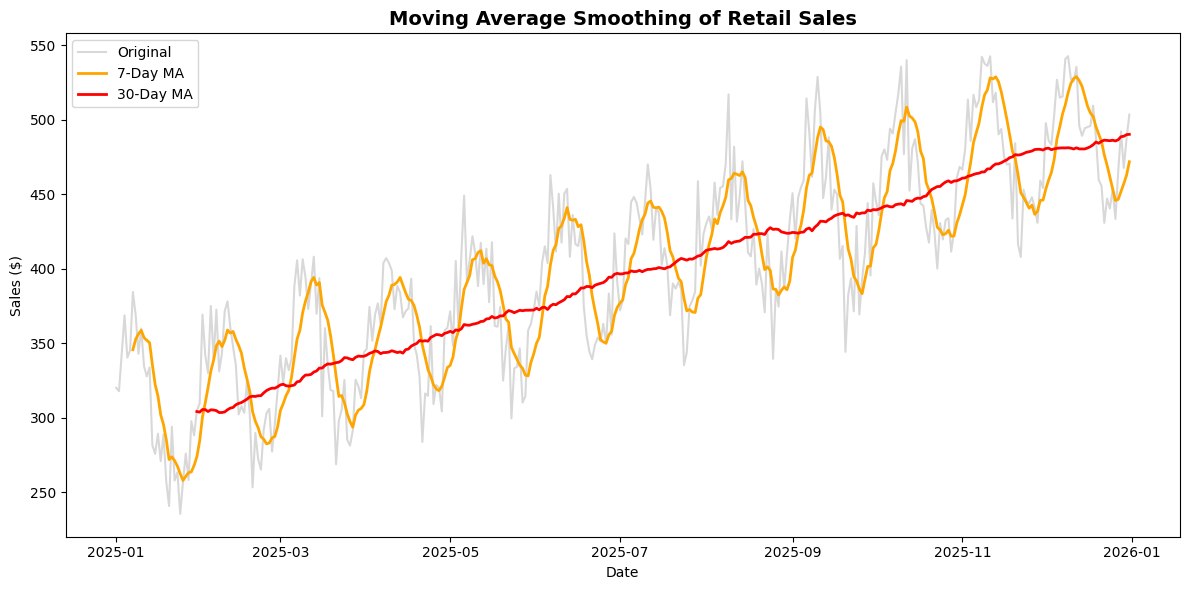

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# Creating a daily time-series dataset for "Retail Performance & Predictive Analytics 2026"
# Covering 1 year to show seasonality
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
n = len(dates)

# Components
trend = np.linspace(300, 500, n)  # Upward trend in sales
seasonality = 50 * np.sin(2 * np.pi * dates.dayofyear / 30.5)  # Monthly cycle
noise = np.random.normal(0, 20, n)
sales = trend + seasonality + noise

df = pd.DataFrame({'Date': dates, 'Sales': sales})
df.set_index('Date', inplace=True)

# 1. Plot the time-series data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label='Daily Sales', alpha=0.7, color='steelblue')
plt.title('Retail Sales Time Series (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('time_series_plot.png')
plt.show()

# 2. Decompose the series (Additive model)
decomposition = seasonal_decompose(df['Sales'], model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('time_series_decomposition.png')
plt.show()

# 3. Moving Average Smoothing
df['MA7'] = df['Sales'].rolling(window=7).mean()  # 7-day moving average
df['MA30'] = df['Sales'].rolling(window=30).mean() # 30-day moving average

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label='Original', alpha=0.3, color='gray')
plt.plot(df.index, df['MA7'], label='7-Day MA', color='orange', linewidth=2)
plt.plot(df.index, df['MA30'], label='30-Day MA', color='red', linewidth=2)
plt.title('Moving Average Smoothing of Retail Sales', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('time_series_smoothing.png')
plt.show()